# RETO 2

## que es SAM
Segment Anything Model mas conocido como SAM es un modelo de segmentacion de imagenes que tiene la capacidad de segmentar objetos en imagenes los cuales NO ha sido entrenado previamente (conocido como zero-shot performance) y con una precision muy alta, en algunos casos superando a modelos de segmentacion explicitamente entrenados para un proposito, este modelo es famoso por esta increible versatildiad, y ademas SAM tambien tiene la capacidad de segmentar en base de indicaciones.

Primero procedemos importanto ultralytics que es la libreria que nos va a proporcionar el modelo de SAM

In [10]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.171  Python-3.14.3 torch-2.14.1+cu132 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 63.7 GB RAM, 345.8/474.7 GB disk)


Luego importamos pytorch para que SAM trabaje en la GPU

In [11]:
import torch

print(f"PyTorch version: {torch.version}") 
cuda_available = torch.cuda.is_available() 
print(f"CUDA available: {cuda_available}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Using device: {device}")

PyTorch version: <module 'torch.version' from 'c:\\Users\\USER\\Desktop\\uni\\semestre 9\\vision por computadora\\entregable 1\\vision-por-computador\\.venv\\Lib\\site-packages\\torch\\version.py'>
CUDA available: True
Using device: cuda


aqui importamos todas las librerias necesarias

In [13]:

import os
import random
import cv2
import xml.etree.ElementTree as ET
import numpy as np
from ultralytics import SAM
import gc
import matplotlib.pyplot as plt

vamos a escoger 21 imagenes aleatorias de las carpetas ship, multi y coast_ship y vamos a hacer que SAM realiza una segmentacion automatica sobre estas imagenes

Model summary: 178 layers, 93,735,472 parameters, 93,735,472 gradients

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\coast_ship\x0566.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 3107.7ms
Speed: 5.6ms preprocess, 3107.7ms inference, 2.1ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\multi\m0230.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 3100.0ms
Speed: 5.2ms preprocess, 3100.0ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\ship\s0913.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 3020.1ms
Speed: 5.0ms preprocess, 3020.1ms inference, 1.2ms post

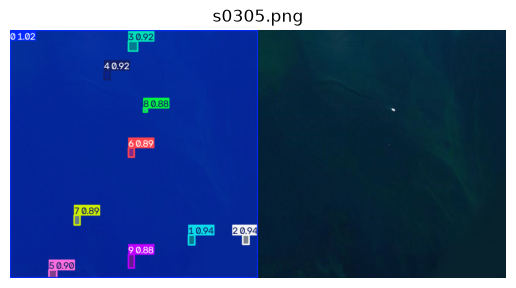

In [ ]:
model = SAM("sam_b.pt")
model.info()
dataset_base_path = "MASATI-v2"
masati_content = os.listdir(dataset_base_path)
with_labels = {}

# find folders with labels
for folder in masati_content: 
    if folder.endswith("_labels"):
        with_labels[folder.replace("_labels", "")] = folder

images =[]

# por cada carpeta de las ya mencionadas se saca una imagen aleatoria y despues de repito el mismo proceso 7 veces
for _ in range(7):
    for data, label in with_labels.items():
        data_path = os.path.join(dataset_base_path, data)
        image = random.choice(os.listdir(data_path))

        # se guardan las imagenes seleccionadas
        images.append(os.path.join(data_path, image))

        # se realiza la inferencia del modelo
        results = model(os.path.join(data_path, image))

        img = results[0].plot()

        #se guarda la imagen
        cv2.imwrite(os.path.join(dataset_base_path, "AutoSegmentacion", image[:-4]+"_AUTO.png"), img)

# Convertir a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_ori = cv2.cvtColor(cv2.imread(images[-1]), cv2.COLOR_BGR2RGB)
img_CONCAT = cv2.hconcat([img_rgb, img_ori])

# Mostrar con Matplotlib
plt.imshow(img_CONCAT)
plt.title(image)
plt.axis("off")
plt.show()

# limpiar la ram y vram
gc.collect()
torch.cuda.empty_cache()


Como se puede observar en esta imagen SAM detecto diferencias entre el mar, el barco y texturas de la superficie del mar que SAM identifico como objetos unicos, se puede observar que en este contexto de imagenes satelitales las segmentacion automatica de SAM se puede confundir facilmente y marcar objetos que en realidad no existen, esto se puede explicar porque SAM esta entrenado con imagenes regulares de paisajes, objetos, animales, personas, etc, y no consta de imagenes satelitales, asi que no fue entrenado en este contexto, pero aun asi para la mayoria de imagenes logro segmentar el barco exitosamente.

Ahora la segmentacion de SAM va a ser ayudada por las labels de las imagenes y despues estas nuevas labels generadas por SAM se van a guardar en xml

In [ ]:
def save_voc_xml(results, image_path, xml_path, class_name="ship"):
    """
    Guarda las bboxes en un archivo xml en la ruta xml especificada y con los datos de la carpeta
    de la imagen y el nombre
    """
    h, w = results.orig_shape            # (alto, ancho) de la imagen original
    boxes = results.boxes.xyxy.cpu().numpy()

    root = ET.Element("annotation")
    ET.SubElement(root, "folder").text = os.path.basename(os.path.dirname(image_path))
    ET.SubElement(root, "filename").text = os.path.basename(image_path)

    size = ET.SubElement(root, "size")
    ET.SubElement(size, "width").text = str(w)
    ET.SubElement(size, "height").text = str(h)
    ET.SubElement(size, "depth").text = "3"

    for x1, y1, x2, y2 in boxes:
        obj = ET.SubElement(root, "object")
        ET.SubElement(obj, "name").text = class_name
        ET.SubElement(obj, "pose").text = "Unspecified"
        ET.SubElement(obj, "truncated").text = "0"
        ET.SubElement(obj, "difficult").text = "0"

        bnd = ET.SubElement(obj, "bndbox")
        ET.SubElement(bnd, "xmin").text = str(int(round(x1)))
        ET.SubElement(bnd, "ymin").text = str(int(round(y1)))
        ET.SubElement(bnd, "xmax").text = str(int(round(x2)))
        ET.SubElement(bnd, "ymax").text = str(int(round(y2)))

    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ")          
    tree.write(xml_path, encoding="utf-8", xml_declaration=True)

dataset_base_path = "MASATI-v2"
xml_path = os.path.join("MASATI-v2", "ships_SAM")

#recorre las imagenes seleccionadas en el paso anterior
for image in images:
    split = image.split('\\')
    tree = ET.parse(os.path.join(dataset_base_path, split[1]+"_labels", split[2].replace(".png", ".xml")))
    root = tree.getroot()
    rectangles = []

    #crea las bboxes de los labels
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rectangles.append((xmin, ymin, xmax, ymax))

    #realiza la inferencia de SAM asistida por las bboxes
    results = model(image, bboxes=rectangles)

    #guarda las bboxes generadas por SAM en xml
    save_voc_xml(results[0], image, os.path.join(xml_path,split[2][:-4]+".xml"), class_name="ship")

#limpiar ram y vram
gc.collect()
torch.cuda.empty_cache()



image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\coast_ship\x0566.png: 1024x1024 1 0, 319.0ms
Speed: 5.9ms preprocess, 319.0ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\multi\m0230.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 248.4ms
Speed: 5.5ms preprocess, 248.4ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\ship\s0913.png: 1024x1024 1 0, 228.0ms
Speed: 5.4ms preprocess, 228.0ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\coast_ship\x0412.png: 1024x1024 1 0, 228.9ms

Un punto a notar de esta celda es que la inferencia de SAM con sugerencia fue mucho mas rapida que la auto segmentacion (200ms vs 3000ms), este comportamiento se debe al hecho de que gracias a las sugerencias el modelo procesa la imagen una vez y solo genera una mascara, mientras que en la autosegmentacion el modelo tiene que procesar la imagen varias veces y generar mascaras para todos los objetos de la imagen, lo que concluye en multiples inferencias.

En esta ultima celda vamos a visualizar las bboxes de SAM y las originales

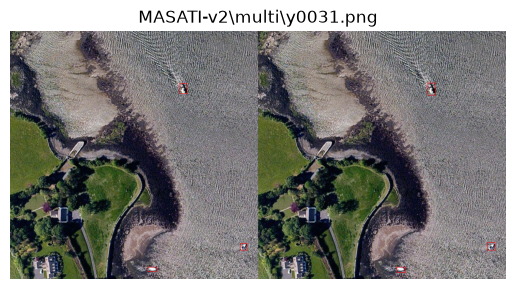

In [ ]:
dataset_base_path = "MASATI-v2"
SAM_path = os.path.join(dataset_base_path, "ships_SAM")
SAM_content = os.listdir(SAM_path)

# recorre todos los archivos xml
for file in SAM_content:

    tree = ET.parse(os.path.join(SAM_path, file))
    root = tree.getroot()

    image = os.path.join(dataset_base_path, root.find('folder').text, root.find('filename').text)

    rectangles_SAM = []

    #crea las bboxes de SAM
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rectangles_SAM.append((xmin, ymin, xmax, ymax))


    cv2_img = cv2.imread(image)
    img_SAM = cv2_img.copy()

    #dibuja las bboxes de SAM en la imagen original
    for (x1,y1,x2,y2) in rectangles_SAM:
        cv2.rectangle(img_SAM, (x1,y1), (x2, y2), (0,0,255), 1)

    tree = ET.parse(os.path.join(dataset_base_path, root.find('folder').text+"_labels", root.find('filename').text.replace(".png", ".xml")))
    root = tree.getroot()
    rectangles_xml = []

    #crea las bboxes de las labels
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rectangles_xml.append((xmin, ymin, xmax, ymax))

    img_xml = cv2_img.copy()

    #dibuja las bboxes de las labels en la imagen original
    for (x1,y1,x2,y2) in rectangles_xml:
        cv2.rectangle(img_xml, (x1,y1), (x2, y2), (0,0,255), 1)

    #une las 2 imagenes de SAM y labes en una sola
    img_CONCAT = cv2.hconcat([img_SAM,img_xml])

    #muestra la imagen
    cv2.imshow(image, img_CONCAT)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# Convertir a RGB
img_SAM = cv2.cvtColor(img_SAM, cv2.COLOR_BGR2RGB)
img_xml = cv2.cvtColor(img_xml, cv2.COLOR_BGR2RGB)
img_CONCAT = cv2.hconcat([img_SAM, img_xml])

# Mostrar con Matplotlib
plt.imshow(img_CONCAT)
plt.title(image)
plt.axis("off")
plt.show()

### Conclusion

SAM es un modelo muy versatil y potente, gracias a sus capacidades de zero-shot transfer puede ser util en muchos contextos sin necesidad de sobreajustamiento, pero en este contexto la capacidad de auto segmentacion de SAM no es muy util porque crea objetos de la nada, mas sin embargo si usamos otra de sus funcionalidades estrella, esta siendo la inferencia con sugerencias puede crear unas segmentaciones muy precisas y rapidas, con esto podemos evidenciar que aun en un contexto desconocido con las condiciones adecuadas puede rendir excelentemente y dar mas razon a su alaba versatilidad.